In [1]:
import pandas as pd

print("Loading dataset...")
df = pd.read_csv('train.csv')

print("\n--- 1. COLUMNS ---")
print(df.columns.tolist())

print("\n--- 2. FIRST 5 ROWS ---")
display(df.head())

print("\n--- 3. DATE RANGE ---")
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

print("\n--- 4. STORES & CATEGORIES ---")
print("Total unique stores:", df['store_nbr'].nunique())
print("Total product families:", df['family'].nunique())

print("\n--- 5. MISSING VALUES ---")
print(df.isnull().sum())

Loading dataset...

--- 1. COLUMNS ---
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

--- 2. FIRST 5 ROWS ---


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0



--- 3. DATE RANGE ---
Start Date: 2013-01-01
End Date: 2017-08-15

--- 4. STORES & CATEGORIES ---
Total unique stores: 54
Total product families: 33

--- 5. MISSING VALUES ---
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


Generating visualizations... (Grouping 3 million rows takes a few seconds)


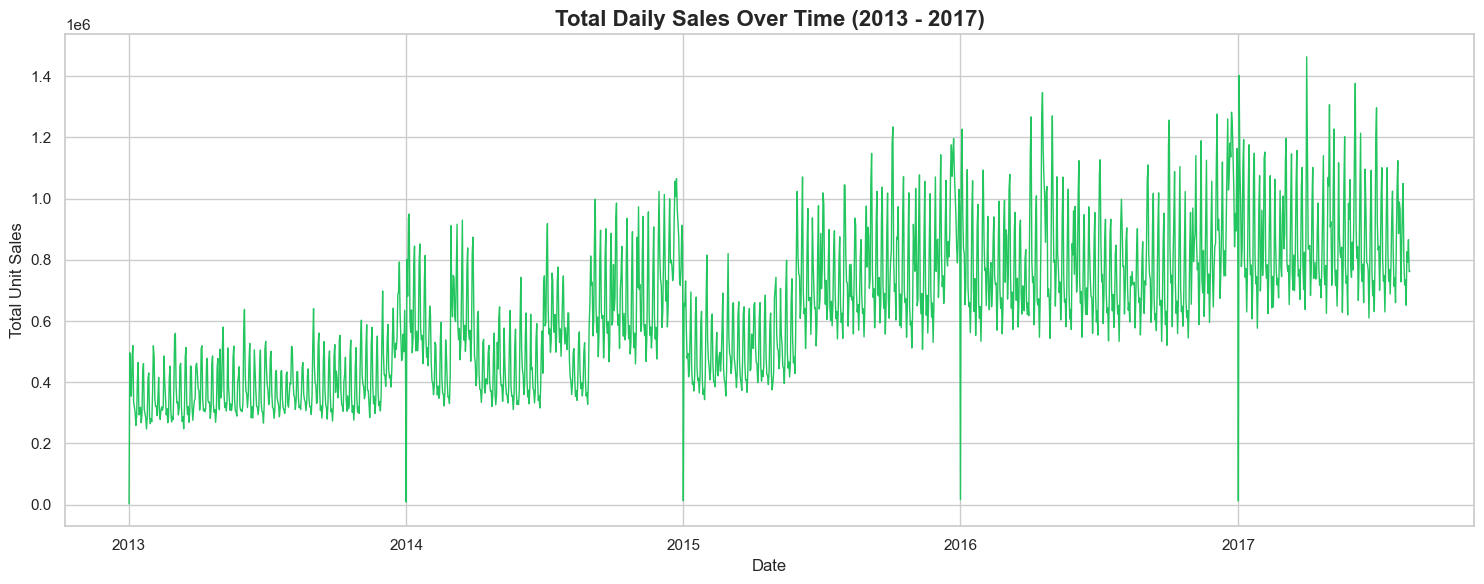

C:\Users\mrizn\AppData\Local\Temp\ipykernel_8860\948724428.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_families, x='sales', y='family', palette='Greens_r')


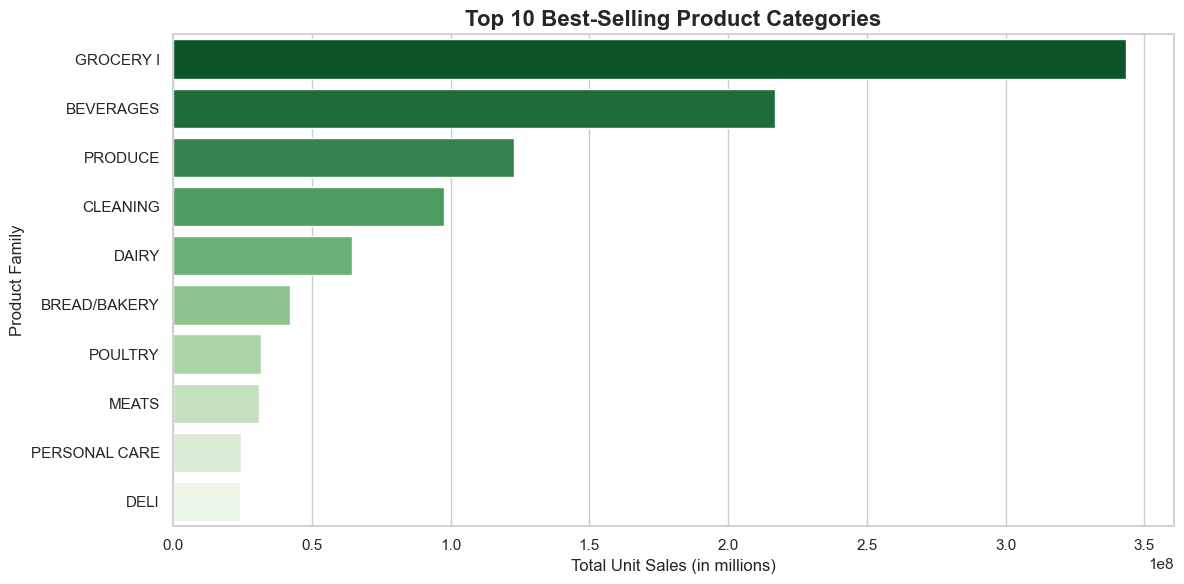

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for professional-looking charts
sns.set_theme(style="whitegrid")

print("Generating visualizations... (Grouping 3 million rows takes a few seconds)")

# --- Chart 1: Overall Sales Trend Over Time ---
# Group the data by date and sum up the sales for all stores
daily_sales = df.groupby('date')['sales'].sum().reset_index()
# Convert the 'date' string to an actual datetime object for plotting
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_sales, x='date', y='sales', color='#22c55e', linewidth=1)
plt.title('Total Daily Sales Over Time (2013 - 2017)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Unit Sales', fontsize=12)
plt.tight_layout()
plt.show()

# --- Chart 2: Top 10 Product Families ---
# Group by family, sum the sales, sort highest to lowest, and grab the top 10
top_families = df.groupby('family')['sales'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_families, x='sales', y='family', palette='Greens_r')
plt.title('Top 10 Best-Selling Product Categories', fontsize=16, fontweight='bold')
plt.xlabel('Total Unit Sales (in millions)', fontsize=12)
plt.ylabel('Product Family', fontsize=12)
plt.tight_layout()
plt.show()